   BOT UNIFICADO — ESTRATEGIA + RIESGO INTEGRADOS
   Cuenta: $100,000 | DD: 6% | Objetivo: 6%
   Estrategia: Donchian30 + SMA200 + CCI>100
   SL: 0.5xATR | TP: 1.5xATR | Ratio: 3:1
   Breakeven WR: 25.0%

[1/6] Cargando datos...
   Cargadas 49,967 velas | 2024-03-12 a 2026-04-24

[2/6] Calculando indicadores...
   Dataset procesado: 49,768 velas

[3/6] Dividiendo datos...
   Entrenamiento: 30,370 velas hasta 2025-06-30
   Test: 11,924 velas
   Forward: 7,474 velas

[4/6] Entrenando modelo ML...
   AUC entrenamiento: 0.5077

[5/6] Ejecutando backtests...

   → TEST...
      Balance: $104,056.17 | Rentab: +4.06%
      Ops: 258 | WR: 29.5% | PF: 1.239

   → FORWARD...
      Balance: $102,024.61 | Rentab: +2.02%
      Ops: 142 | WR: 29.6% | PF: 1.216


   INFORME FINAL — BOT UNIFICADO

─────────────────────────────────────────────────────────────────
  TEST
─────────────────────────────────────────────────────────────────

  RENDIMIENTO
  Balance inicial               : $100,000.00
  Balan

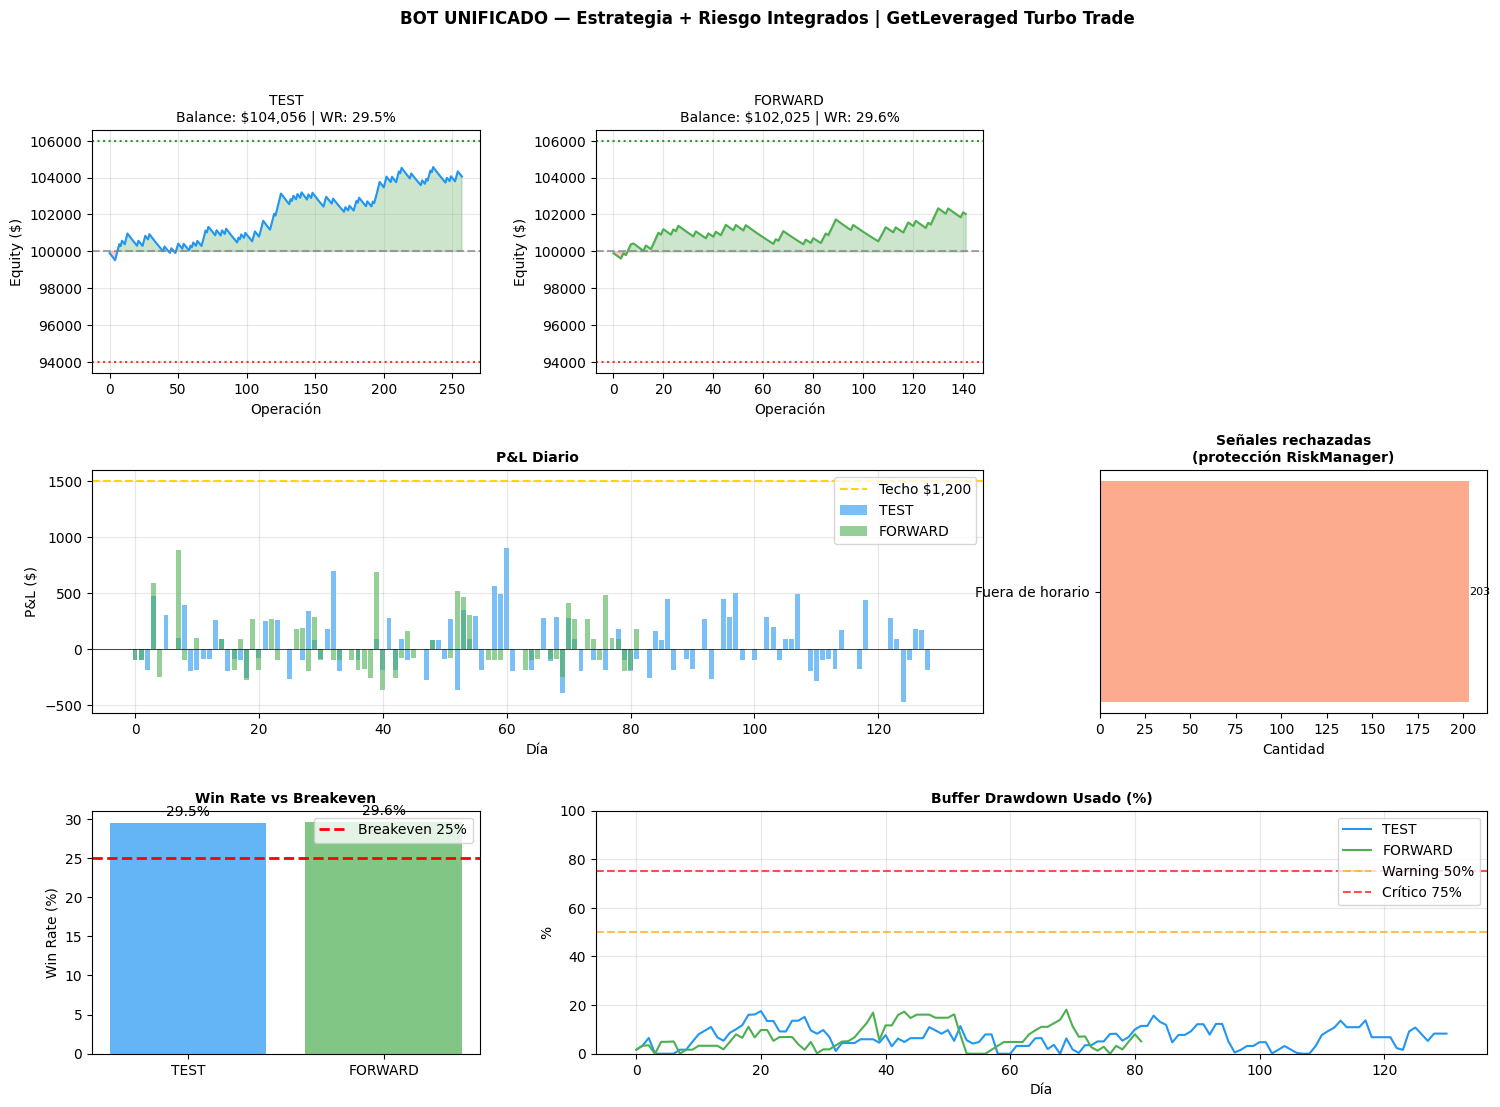


✅ Gráfico guardado: backtest_unificado.png

   BACKTEST COMPLETADO


In [4]:
# ============================================================
# BOT UNIFICADO — BACKTEST COMPLETO EN COLAB
# GetLeveraged Turbo Trade | CFD US500 M15
# ============================================================
# Ejecutar en Google Colab con datos_US500.csv
# ============================================================

!pip install statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from statsmodels.stats.proportion import proportion_confint
import scipy.stats as stats

warnings.filterwarnings('ignore')

# ============================================================
# 1. CONFIGURACIÓN UNIFICADA
# ============================================================

CONFIG = {
    # ── Cuenta GetLeveraged Turbo Trade ──
    "initial_balance": 100_000,
    "daily_loss_limit_pct": 0.03,           # 3%
    "trailing_drawdown_pct": 0.06,          # 6%
    "profit_target_pct": 0.06,              # 6%
    "consistency_rule_pct": 0.20,           # 20%
    "min_trade_duration_minutes": 2,
    "max_leverage": 30,

    # ── Límites internos conservadores ──
    "internal_daily_risk_max": 1500,
    "daily_profit_ceiling": 1500,
    "daily_profit_ceiling_enabled": True,
    "max_trades_per_day": 8,
    "max_trades_per_day_enabled": True,

    # ── Riesgo por operación ──
    "max_risk_per_trade": 200,
    "min_risk_per_trade": 40,
    "min_signal_score": 45,

    # ── Horarios (Madrid) ──
    "trading_start_hour": 8,
    "trading_end_hour": 22,
    "us_open_start": 15.50,
    "us_open_end": 15.75,
    "filter_us_open": False,

    # ── Anti-sobreoperar ──
    "min_bars_between_entries": 2,
    "anti_consecutive_enabled": True,
    "max_positions": 1,

    # ── Estrategia Donchian + CCI + ML ──
    "donchian_period": 30,
    "sma_period": 200,
    "cci_period": 14,
    "cci_threshold": 100,
    "atr_period": 14,
    "sl_multiplier": 0.5,
    "tp_multiplier": 1.5,
    "ml_threshold": 0.45,
    "lookforward_bars": 30,
    "max_bars_in_trade": 32,            # 8 horas en M15

    # ── CFD US500 ──
    "point_value_per_lot": 1,
    "symbol": "US500",
    "timeframe": "M15",

    # ── Alertas ──
    "alert_threshold_warning": 0.50,
    "alert_threshold_critical": 0.75,

    # ── División temporal ──
    # ── División temporal ──
    "train_end_date": "2025-06-30",    # Entrenamiento: ~15 meses
    "test_end_date": "2025-12-31",     # Backtest: ~6 meses
    # Forward: enero 2026 - abril 2026 (~4 meses)


    # ── Modo ──
    "account_mode": "EVALUACION"
}

# Breakeven matemático
WR_BREAKEVEN = CONFIG["sl_multiplier"] / (CONFIG["sl_multiplier"] + CONFIG["tp_multiplier"]) * 100

print("=" * 65)
print("   BOT UNIFICADO — ESTRATEGIA + RIESGO INTEGRADOS")
print("=" * 65)
print(f"   Cuenta: ${CONFIG['initial_balance']:,} | DD: {CONFIG['trailing_drawdown_pct']*100:.0f}% | Objetivo: {CONFIG['profit_target_pct']*100:.0f}%")
print(f"   Estrategia: Donchian{CONFIG['donchian_period']} + SMA{CONFIG['sma_period']} + CCI>{CONFIG['cci_threshold']}")
print(f"   SL: {CONFIG['sl_multiplier']}xATR | TP: {CONFIG['tp_multiplier']}xATR | Ratio: {CONFIG['tp_multiplier']/CONFIG['sl_multiplier']:.0f}:1")
print(f"   Breakeven WR: {WR_BREAKEVEN:.1f}%")
print("=" * 65)


# ============================================================
# 2. CLASES DE RIESGO (del módulo original)
# ============================================================

class ConsistencyTracker:
    """Monitorea la regla del 20%: mejor día ≤ 20% del profit total."""

    def __init__(self, config: dict):
        self.threshold = config.get("consistency_rule_pct", 0.20)
        self.daily_profits = {}

    def update_day(self, fecha, pnl: float) -> None:
        if pnl > 0:
            self.daily_profits[fecha] = pnl

    def get_score(self) -> dict:
        if not self.daily_profits:
            return {"best_day_pnl": 0, "total_profit": 0, "consistency_pct": 0, "is_compliant": True}

        total = sum(self.daily_profits.values())
        if total <= 0:
            return {"best_day_pnl": 0, "total_profit": 0, "consistency_pct": 0, "is_compliant": True}

        best_date = max(self.daily_profits, key=self.daily_profits.get)
        best_pnl = self.daily_profits[best_date]
        pct = (best_pnl / total) * 100

        return {
            "best_day_pnl": round(best_pnl, 2),
            "best_day_date": best_date,
            "total_profit": round(total, 2),
            "consistency_pct": round(pct, 2),
            "is_compliant": pct <= (self.threshold * 100)
        }

    def get_summary(self) -> dict:
        score = self.get_score()
        return {
            "score_pct": score["consistency_pct"],
            "limite_pct": self.threshold * 100,
            "cumple": score["is_compliant"]
        }


class AntiConsecutiveTracker:
    """Evita entradas en velas consecutivas."""

    def __init__(self, config: dict):
        self.min_bars = config.get("min_bars_between_entries", 2)
        self.enabled = config.get("anti_consecutive_enabled", True)
        self.last_entry_bar_index = None

    def register_entry(self, bar_index: int) -> None:
        self.last_entry_bar_index = bar_index

    def can_enter(self, current_bar_index: int) -> Tuple[bool, str]:
        if not self.enabled:
            return True, "Filtro desactivado"
        if self.last_entry_bar_index is None:
            return True, "Primera entrada"

        bars_since = current_bar_index - self.last_entry_bar_index
        if bars_since < self.min_bars:
            return False, f"Anti-consecutivo: {bars_since} velas (mín: {self.min_bars})"
        return True, "OK"

    def reset_day(self) -> None:
        self.last_entry_bar_index = None


class RiskManager:
    """Gestor de riesgo completo para cuentas de fondeo."""

    def __init__(self, config: dict):
        self.config = config
        self.initial_balance = config["initial_balance"]
        self.balance = config["initial_balance"]
        self.equity = config["initial_balance"]
        self.max_equity = config["initial_balance"]

        self.current_day = None
        self.day_start_balance = config["initial_balance"]
        self.daily_pnl = 0
        self.daily_risk_used = 0
        self.daily_trades = []

        self.blocked_today = False
        self.blocked_total = False
        self.block_reason = ""
        self.ceiling_reached_today = False
        self.max_trades_reached_today = False
        self.profit_target_reached = False

        self.daily_log = []
        self.trade_log = []
        self.rejection_log = defaultdict(int)

        self.consistency = ConsistencyTracker(config)
        self.anti_consecutive = AntiConsecutiveTracker(config)

    def update_day(self, timestamp: datetime) -> None:
        day = timestamp.date()
        if self.current_day != day:
            if self.current_day is not None:
                self._close_day()

            self.current_day = day
            self.day_start_balance = self.balance
            self.daily_pnl = 0
            self.daily_risk_used = 0
            self.daily_trades = []
            self.blocked_today = False
            self.ceiling_reached_today = False
            self.max_trades_reached_today = False
            self.anti_consecutive.reset_day()

    def _close_day(self) -> None:
        summary = self._get_daily_summary_internal()
        self.daily_log.append(summary)
        if summary["pnl_dia"] > 0:
            self.consistency.update_day(summary["fecha"], summary["pnl_dia"])

    def _get_daily_summary_internal(self) -> dict:
        floor = self.get_drawdown_floor()
        total = len(self.daily_trades)
        wins = sum(1 for t in self.daily_trades if t["pnl"] > 0)
        return {
            "fecha": self.current_day,
            "balance_inicio": round(self.day_start_balance, 2),
            "balance": round(self.balance, 2),
            "equity": round(self.equity, 2),
            "equity_max": round(self.max_equity, 2),
            "limite_drawdown": round(floor, 2),
            "distancia_drawdown": round(self.equity - floor, 2),
            "buffer_usado_pct": round(self.get_buffer_used_pct(), 2),
            "pnl_dia": round(self.daily_pnl, 2),
            "rentabilidad_dia_pct": round((self.daily_pnl / self.day_start_balance) * 100, 4) if self.day_start_balance > 0 else 0,
            "total_operaciones": total,
            "operaciones_ganadoras": wins,
            "win_rate": round((wins / total * 100) if total > 0 else 0, 2),
            "modo": self.get_risk_mode(),
            "bloqueado_hoy": self.blocked_today,
            "techo_alcanzado": self.ceiling_reached_today,
            "limite_ops_alcanzado": self.max_trades_reached_today
        }

    def update_equity(self, equity: float) -> None:
        self.equity = equity
        if equity > self.max_equity:
            self.max_equity = equity
            self._check_profit_target()

    def _check_profit_target(self) -> None:
        target = self.initial_balance * (1 + self.config["profit_target_pct"])
        if self.max_equity >= target:
            self.profit_target_reached = True

    def get_drawdown_floor(self) -> float:
        if self.profit_target_reached:
            return self.initial_balance
        return self.max_equity * (1 - self.config["trailing_drawdown_pct"])

    def get_buffer_ratio(self) -> float:
        floor = self.get_drawdown_floor()
        total_buffer = self.max_equity - floor
        current_buffer = self.equity - floor
        if total_buffer <= 0:
            return 0
        return max(0, min(current_buffer / total_buffer, 1))

    def get_buffer_used_pct(self) -> float:
        return (1 - self.get_buffer_ratio()) * 100

    def get_risk_mode(self) -> str:
        buffer = self.get_buffer_ratio()
        if buffer > 0.70:
            return "NORMAL"
        elif buffer > 0.40:
            return "CONSERVADOR"
        elif buffer > 0.20:
            return "SUPERVIVENCIA"
        else:
            return "BLOQUEADO"

    def check_trailing_drawdown(self) -> Tuple[bool, str]:
        floor = self.get_drawdown_floor()
        if self.equity <= floor:
            self.blocked_total = True
            self.block_reason = "Drawdown trailing alcanzado"
            return False, self.block_reason
        return True, "OK"

    def check_daily_loss(self) -> Tuple[bool, str]:
        official_limit = self.day_start_balance * self.config["daily_loss_limit_pct"]
        internal_limit = self.config["internal_daily_risk_max"]

        if self.daily_pnl <= -official_limit:
            self.blocked_today = True
            return False, "Pérdida diaria 3% alcanzada"
        if self.daily_pnl <= -internal_limit:
            self.blocked_today = True
            return False, "Límite interno diario alcanzado"
        return True, "OK"

    def check_daily_ceiling(self) -> Tuple[bool, str]:
        if not self.config.get("daily_profit_ceiling_enabled", True):
            return True, "OK"
        ceiling = self.config.get("daily_profit_ceiling", 1200)
        if self.daily_pnl >= ceiling:
            self.ceiling_reached_today = True
            return False, f"Techo diario ${ceiling} alcanzado"
        return True, "OK"

    def check_max_trades_per_day(self) -> Tuple[bool, str]:
        if not self.config.get("max_trades_per_day_enabled", True):
            return True, "OK"
        max_trades = self.config.get("max_trades_per_day", 5)
        if len(self.daily_trades) >= max_trades:
            self.max_trades_reached_today = True
            return False, f"Límite {max_trades} ops/día alcanzado"
        return True, "OK"

    def check_trading_hours(self, timestamp: datetime) -> Tuple[bool, str]:
        hour = timestamp.hour
        minute = timestamp.minute
        hora_decimal = hour + minute / 60

        if hour < self.config["trading_start_hour"] or hour >= self.config["trading_end_hour"]:
            return False, "Fuera de horario"

        if self.config.get("filter_us_open", True):
            us_start = self.config.get("us_open_start", 15.50)
            us_end = self.config.get("us_open_end", 15.75)
            if us_start <= hora_decimal < us_end:
                return False, "Filtro apertura US"
        return True, "OK"

    def check_anti_consecutive(self, bar_index: int) -> Tuple[bool, str]:
        return self.anti_consecutive.can_enter(bar_index)

    def calculate_risk_smooth(self, signal_score: float) -> float:
        if signal_score < self.config["min_signal_score"]:
            return 0

        buffer = self.get_buffer_ratio()
        if buffer <= 0.20:
            return 0

        max_risk = self.config["max_risk_per_trade"]
        min_risk = self.config["min_risk_per_trade"]

        scale = (buffer - 0.20) / 0.80
        base_risk = min_risk + (max_risk - min_risk) * scale

        if signal_score >= 80:
            multiplier = 1.0
        elif signal_score >= 65:
            multiplier = 0.75
        else:
            multiplier = 0.50

        risk = base_risk * multiplier
        remaining = self._get_daily_budget() - self.daily_risk_used
        risk = min(risk, remaining)

        if risk < self.config["min_risk_per_trade"]:
            return 0
        return round(risk, 2)

    def _get_daily_budget(self) -> float:
        mode = self.get_risk_mode()
        budgets = {"NORMAL": 1000, "CONSERVADOR": 600, "SUPERVIVENCIA": 250, "BLOQUEADO": 0}
        budget = budgets.get(mode, 0)

        if self.config.get("daily_profit_ceiling_enabled", True):
            ceiling = self.config.get("daily_profit_ceiling", 1200)
            remaining = ceiling - self.daily_pnl
            if remaining < budget:
                budget = max(0, remaining * 0.5)
        return budget

    def calculate_lot_size(self, risk_usd: float, stop_loss_points: float) -> float:
        if stop_loss_points <= 0 or risk_usd <= 0:
            return 0
        return round(risk_usd / (stop_loss_points * self.config["point_value_per_lot"]), 4)

    def evaluate_trade(self, signal: dict, bar_index: int) -> dict:
        timestamp = signal["timestamp"]
        direction = signal["signal"]
        score = signal["signal_score"]
        entry_price = signal["entry_price"]
        sl_points = signal["stop_loss_points"]

        self.update_day(timestamp)

        base = {"allowed": False, "reason": "", "risk_usd": 0, "lot_size": 0, "mode": self.get_risk_mode()}

        if direction == 0:
            return {**base, "reason": "Sin señal"}

        if self.blocked_total:
            self.rejection_log["Cuenta bloqueada"] += 1
            return {**base, "reason": "Cuenta bloqueada"}

        if self.blocked_today:
            self.rejection_log["Bloqueado hoy"] += 1
            return {**base, "reason": "Bloqueado hoy"}

        if self.ceiling_reached_today:
            self.rejection_log["Techo diario"] += 1
            return {**base, "reason": "Techo diario alcanzado"}

        if self.max_trades_reached_today:
            self.rejection_log["Límite ops diarias"] += 1
            return {**base, "reason": "Límite ops diarias"}

        # Verificaciones en cadena
        checks = [
            ("Horario", self.check_trading_hours(timestamp)),
            ("Drawdown", self.check_trailing_drawdown()),
            ("Pérdida diaria", self.check_daily_loss()),
            ("Techo diario", self.check_daily_ceiling()),
            ("Límite ops", self.check_max_trades_per_day()),
            ("Anti-consecutivo", self.check_anti_consecutive(bar_index)),
        ]

        for name, (ok, reason) in checks:
            if not ok:
                self.rejection_log[reason] += 1
                return {**base, "reason": reason}

        risk_usd = self.calculate_risk_smooth(score)
        if risk_usd <= 0:
            self.rejection_log["Riesgo cero (score bajo)"] += 1
            return {**base, "reason": "Riesgo cero (score bajo)"}

        lot_size = self.calculate_lot_size(risk_usd, sl_points)
        if lot_size <= 0:
            self.rejection_log["Lote inválido"] += 1
            return {**base, "reason": "Lote inválido"}

        return {
            "allowed": True,
            "reason": "Autorizada",
            "risk_usd": risk_usd,
            "lot_size": lot_size,
            "mode": self.get_risk_mode()
        }

    def confirm_trade_open(self, risk_usd: float, bar_index: int) -> None:
        self.daily_risk_used += risk_usd
        self.anti_consecutive.register_entry(bar_index)

    def register_trade_result(self, open_time, close_time, pnl: float, details: dict) -> None:
        self.balance += pnl
        self.equity = self.balance
        if self.equity > self.max_equity:
            self.max_equity = self.equity
            self._check_profit_target()

        self.daily_pnl += pnl

        record = {
            "open_time": open_time,
            "close_time": close_time,
            "pnl": round(pnl, 2),
            "balance": round(self.balance, 2),
            "mode": self.get_risk_mode(),
            **details
        }
        self.trade_log.append(record)
        self.daily_trades.append(record)

        self.check_trailing_drawdown()
        self.check_daily_loss()
        self.check_daily_ceiling()

    def get_final_metrics(self) -> dict:
        if self.current_day is not None:
            self._close_day()

        total = len(self.trade_log)
        wins = sum(1 for t in self.trade_log if t["pnl"] > 0)
        total_pnl = sum(t["pnl"] for t in self.trade_log)

        gains = sum(t["pnl"] for t in self.trade_log if t["pnl"] > 0)
        losses = abs(sum(t["pnl"] for t in self.trade_log if t["pnl"] < 0))
        pf = gains / losses if losses > 0 else (float('inf') if gains > 0 else 0)

        return {
            "balance_inicial": self.initial_balance,
            "balance_final": round(self.balance, 2),
            "rentabilidad_pct": round(((self.balance / self.initial_balance) - 1) * 100, 2),
            "equity_maxima": round(self.max_equity, 2),
            "dd_floor_actual": round(self.get_drawdown_floor(), 2),
            "distancia_dd": round(self.balance - self.get_drawdown_floor(), 2),
            "estado": self.get_risk_mode(),
            "bloqueado": self.blocked_total,
            "objetivo_alcanzado": self.profit_target_reached,
            "total_operaciones": total,
            "operaciones_ganadoras": wins,
            "win_rate_global": round((wins / total * 100) if total > 0 else 0, 2),
            "profit_factor": round(pf, 3) if pf != float('inf') else "∞",
            "pnl_total": round(total_pnl, 2),
            "dias_operados": len(self.daily_log),
            "consistencia": self.consistency.get_summary(),
            "rechazos": dict(self.rejection_log)
        }


# ============================================================
# 3. GENERADOR DE SEÑALES (Estrategia)
# ============================================================

class SignalGenerator:
    """Estrategia Donchian + CCI + ML."""

    def __init__(self, config: dict):
        self.config = config
        self.model = None
        self.scaler = None
        self.features = ['cci', 'dist_upper', 'dist_lower', 'dist_sma', 'atr_rel']
        self.is_trained = False

    def calculate_indicators(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # SMA
        df['sma_200'] = df['close'].rolling(self.config['sma_period']).mean()

        # Donchian
        don_p = self.config['donchian_period']
        df['donchian_upper'] = df['high'].rolling(don_p).max().shift(1)
        df['donchian_lower'] = df['low'].rolling(don_p).min().shift(1)

        # ATR
        hl = df['high'] - df['low']
        hc = (df['high'] - df['close'].shift(1)).abs()
        lc = (df['low'] - df['close'].shift(1)).abs()
        tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
        df['atr'] = tr.ewm(alpha=1/self.config['atr_period'], adjust=False).mean()

        # CCI
        cci_p = self.config['cci_period']
        tp = (df['high'] + df['low'] + df['close']) / 3
        sma_tp = tp.rolling(cci_p).mean()
        mean_dev = tp.rolling(cci_p).apply(lambda x: np.abs(x - x.mean()).mean(), raw=True)
        df['cci'] = (tp - sma_tp) / (0.015 * mean_dev)

        # Features ML
        df['dist_upper'] = (df['donchian_upper'] - df['close']) / df['close']
        df['dist_lower'] = (df['close'] - df['donchian_lower']) / df['close']
        df['dist_sma'] = (df['close'] - df['sma_200']) / df['sma_200']
        df['atr_rel'] = df['atr'] / df['close']

        # SL/TP en puntos
        df['stop_loss_points'] = df['atr'] * self.config['sl_multiplier']
        df['take_profit_points'] = df['atr'] * self.config['tp_multiplier']

        return df.dropna().reset_index(drop=True)

    def generate_labels(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        look = self.config['lookforward_bars']
        sl_mult = self.config['sl_multiplier']
        tp_mult = self.config['tp_multiplier']

        closes = df['close'].values
        highs = df['high'].values
        lows = df['low'].values
        opens = df['open'].values
        atrs = df['atr'].values
        n = len(df)

        labels = np.zeros(n, dtype=int)

        for i in range(n - look):
            entry = closes[i]
            atr = atrs[i]
            tp_level = entry + atr * tp_mult
            sl_level = entry - atr * sl_mult

            for j in range(i + 1, min(i + look + 1, n)):
                hit_tp = highs[j] >= tp_level
                hit_sl = lows[j] <= sl_level

                if hit_tp and not hit_sl:
                    labels[i] = 1
                    break
                elif hit_sl and not hit_tp:
                    break
                elif hit_tp and hit_sl:
                    labels[i] = 1 if abs(opens[j] - tp_level) < abs(opens[j] - sl_level) else 0
                    break

        df['label'] = labels
        return df

    def train_model(self, df_train: pd.DataFrame) -> float:
        self.scaler = StandardScaler()
        X = df_train[self.features].values
        y = df_train['label'].values

        self.scaler.fit(X)
        X_scaled = self.scaler.transform(X)

        self.model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
        self.model.fit(X_scaled, y)
        self.is_trained = True

        # AUC en training
        probs = self.model.predict_proba(X_scaled)[:, 1]
        return roc_auc_score(y, probs)

    def evaluate_bar(self, row: pd.Series) -> dict:
        result = {
            'signal': 0,
            'signal_score': 0,
            'entry_price': row['close'],
            'stop_loss_points': row['stop_loss_points'],
            'take_profit_points': row['take_profit_points'],
            'ml_probability': 0.0
        }

        # Condiciones técnicas (solo LONG)
        cond_donchian = row['close'] > row['donchian_upper']
        cond_trend = row['close'] > row['sma_200']
        cond_momentum = row['cci'] > self.config['cci_threshold']

        if not (cond_donchian and cond_trend and cond_momentum):
            return result

        if not self.is_trained:
            result['signal'] = 1
            result['signal_score'] = 60
            return result

        try:
            X = row[self.features].values.reshape(1, -1)
            X_scaled = self.scaler.transform(X)
            prob = self.model.predict_proba(X_scaled)[0][1]
        except Exception:
            return result

        result['ml_probability'] = prob
        result['signal'] = 1

        # Convertir prob (0.5-1.0) a score (50-100)
        if prob >= self.config['ml_threshold']:
            result['signal_score'] = int(50 + (prob - 0.5) * 100)
        else:
            result['signal_score'] = int(prob * 100)

        return result


# ============================================================
# 4. ORQUESTADOR
# ============================================================

class TradingOrchestrator:
    """Une estrategia + riesgo. El RiskManager siempre decide."""

    def __init__(self, config: dict, risk_manager: RiskManager, signal_generator: SignalGenerator):
        self.config = config
        self.rm = risk_manager
        self.sg = signal_generator
        self.position = None
        self.execution_log = []

    def process_bar(self, row: pd.Series, bar_index: int) -> dict:
        timestamp = row['time']
        self.rm.update_day(timestamp)

        # Gestionar posición abierta
        if self.position is not None:
            exit_result = self._check_exit(row, bar_index)
            if exit_result['closed']:
                return {'action': 'CLOSE', 'details': exit_result}

        # Evaluar nueva entrada
        if self.position is None:
            entry_result = self._evaluate_entry(row, bar_index)
            if entry_result['executed']:
                return {'action': 'OPEN', 'details': entry_result}

        return {'action': 'HOLD', 'details': {}}

    def _evaluate_entry(self, row: pd.Series, bar_index: int) -> dict:
        signal_data = self.sg.evaluate_bar(row)

        if signal_data['signal'] == 0:
            return {'executed': False, 'reason': 'Sin señal técnica'}

        trade_request = {
            'timestamp': row['time'],
            'signal': signal_data['signal'],
            'signal_score': signal_data['signal_score'],
            'entry_price': signal_data['entry_price'],
            'stop_loss_points': signal_data['stop_loss_points']
        }

        decision = self.rm.evaluate_trade(trade_request, bar_index)

        if not decision['allowed']:
            return {
                'executed': False,
                'reason': decision['reason'],
                'signal_score': signal_data['signal_score'],
                'ml_prob': signal_data['ml_probability']
            }

        # Abrir posición
        self.position = {
            'open_time': row['time'],
            'open_bar': bar_index,
            'signal': signal_data['signal'],
            'entry_price': signal_data['entry_price'],
            'lot_size': decision['lot_size'],
            'risk_usd': decision['risk_usd'],
            'stop_loss': signal_data['entry_price'] - signal_data['stop_loss_points'],
            'take_profit': signal_data['entry_price'] + signal_data['take_profit_points']
        }

        self.rm.confirm_trade_open(decision['risk_usd'], bar_index)

        return {
            'executed': True,
            'entry_price': signal_data['entry_price'],
            'lot_size': decision['lot_size'],
            'risk_usd': decision['risk_usd'],
            'mode': decision['mode'],
            'signal_score': signal_data['signal_score'],
            'ml_prob': signal_data['ml_probability']
        }

    def _check_exit(self, row: pd.Series, bar_index: int) -> dict:
        if self.position is None:
            return {'closed': False}

        pos = self.position
        entry = pos['entry_price']
        tp = pos['take_profit']
        sl = pos['stop_loss']
        lot = pos['lot_size']
        pv = self.config['point_value_per_lot']

        exit_price = None
        exit_reason = None

        # Check TP
        if row['high'] >= tp:
            exit_price = tp
            exit_reason = 'TP'

        # Check SL
        if exit_price is None and row['low'] <= sl:
            exit_price = sl
            exit_reason = 'SL'

        # Check tiempo máximo
        bars_in_trade = bar_index - pos['open_bar']
        if exit_price is None and bars_in_trade >= self.config.get('max_bars_in_trade', 32):
            exit_price = row['close']
            exit_reason = 'TIEMPO'

        if exit_price is None:
            return {'closed': False}

        pnl = (exit_price - entry) * lot * pv

        self.rm.register_trade_result(
            pos['open_time'], row['time'], pnl,
            {'entry_price': entry, 'exit_price': exit_price, 'exit_reason': exit_reason, 'lot_size': lot}
        )

        self.execution_log.append({
            'open_time': pos['open_time'],
            'close_time': row['time'],
            'entry_price': entry,
            'exit_price': exit_price,
            'exit_reason': exit_reason,
            'pnl': pnl,
            'lot_size': lot,
            'bars_in_trade': bars_in_trade
        })

        self.position = None

        return {
            'closed': True,
            'exit_reason': exit_reason,
            'exit_price': exit_price,
            'pnl': pnl,
            'balance': self.rm.balance
        }


# ============================================================
# 5. BACKTEST COMPLETO
# ============================================================

def run_backtest(df: pd.DataFrame, config: dict, period_name: str) -> dict:
    """Ejecuta backtest sobre un período."""
    rm = RiskManager(config)
    sg = SignalGenerator(config)
    sg.model = global_model
    sg.scaler = global_scaler
    sg.is_trained = True

    orchestrator = TradingOrchestrator(config, rm, sg)

    for bar_idx, (_, row) in enumerate(df.iterrows()):
        orchestrator.process_bar(row, bar_idx)
        if rm.blocked_total:
            break

    return {
        'metrics': rm.get_final_metrics(),
        'daily': pd.DataFrame(rm.daily_log),
        'trades': pd.DataFrame(rm.trade_log),
        'executions': orchestrator.execution_log
    }


# ============================================================
# 6. EJECUCIÓN PRINCIPAL
# ============================================================

print("\n[1/6] Cargando datos...")
df = pd.read_csv('datos_US500.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)
print(f"   Cargadas {len(df):,} velas | {df['time'].min().date()} a {df['time'].max().date()}")

print("\n[2/6] Calculando indicadores...")
sg = SignalGenerator(CONFIG)
df = sg.calculate_indicators(df)
df = sg.generate_labels(df)
print(f"   Dataset procesado: {len(df):,} velas")

print("\n[3/6] Dividiendo datos...")
train_end = CONFIG['train_end_date']
test_end = CONFIG['test_end_date']

df_train = df[df['time'] <= train_end].copy()
df_test = df[(df['time'] > train_end) & (df['time'] <= test_end)].copy()
df_forward = df[df['time'] > test_end].copy()

print(f"   Entrenamiento: {len(df_train):,} velas hasta {train_end}")
print(f"   Test: {len(df_test):,} velas")
print(f"   Forward: {len(df_forward):,} velas")

print("\n[4/6] Entrenando modelo ML...")
auc_train = sg.train_model(df_train)
global_model = sg.model
global_scaler = sg.scaler
print(f"   AUC entrenamiento: {auc_train:.4f}")

print("\n[5/6] Ejecutando backtests...")

results = {}

if len(df_test) > 0:
    print("\n   → TEST...")
    results['TEST'] = run_backtest(df_test.reset_index(drop=True), CONFIG, 'TEST')
    m = results['TEST']['metrics']
    print(f"      Balance: ${m['balance_final']:,.2f} | Rentab: {m['rentabilidad_pct']:+.2f}%")
    print(f"      Ops: {m['total_operaciones']} | WR: {m['win_rate_global']:.1f}% | PF: {m['profit_factor']}")

if len(df_forward) > 0:
    print("\n   → FORWARD...")
    results['FORWARD'] = run_backtest(df_forward.reset_index(drop=True), CONFIG, 'FORWARD')
    m = results['FORWARD']['metrics']
    print(f"      Balance: ${m['balance_final']:,.2f} | Rentab: {m['rentabilidad_pct']:+.2f}%")
    print(f"      Ops: {m['total_operaciones']} | WR: {m['win_rate_global']:.1f}% | PF: {m['profit_factor']}")


# ============================================================
# 7. INFORME FINAL
# ============================================================

print("\n\n" + "=" * 65)
print("   INFORME FINAL — BOT UNIFICADO")
print("=" * 65)

for period, data in results.items():
    m = data['metrics']
    c = m['consistencia']

    print(f"\n{'─'*65}")
    print(f"  {period}")
    print(f"{'─'*65}")

    print(f"\n  RENDIMIENTO")
    print(f"  {'Balance inicial':<30}: ${m['balance_inicial']:,.2f}")
    print(f"  {'Balance final':<30}: ${m['balance_final']:,.2f}")
    print(f"  {'Rentabilidad':<30}: {m['rentabilidad_pct']:+.2f}%")
    print(f"  {'Objetivo alcanzado':<30}: {'✅' if m['objetivo_alcanzado'] else '❌'}")

    print(f"\n  OPERACIONES")
    print(f"  {'Total':<30}: {m['total_operaciones']}")
    print(f"  {'Ganadoras':<30}: {m['operaciones_ganadoras']}")
    print(f"  {'Win rate':<30}: {m['win_rate_global']:.1f}% (breakeven: {WR_BREAKEVEN:.1f}%)")
    print(f"  {'Profit factor':<30}: {m['profit_factor']}")

    print(f"\n  RIESGO")
    print(f"  {'Equity máxima':<30}: ${m['equity_maxima']:,.2f}")
    print(f"  {'Floor drawdown':<30}: ${m['dd_floor_actual']:,.2f}")
    print(f"  {'Distancia al floor':<30}: ${m['distancia_dd']:,.2f}")
    print(f"  {'Bloqueado':<30}: {'⛔' if m['bloqueado'] else '✅'}")

    print(f"\n  CONSISTENCIA (regla 20%)")
    print(f"  {'Score':<30}: {c['score_pct']:.1f}% (máx {c['limite_pct']:.0f}%)")
    print(f"  {'Cumple':<30}: {'✅' if c['cumple'] else '⚠️'}")

    print(f"\n  RECHAZOS (protección del RiskManager)")
    for reason, count in m['rechazos'].items():
        print(f"  {'  ' + reason:<30}: {count}")


# ============================================================
# 8. VISUALIZACIONES
# ============================================================

print("\n\n[6/6] Generando gráficos...")

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

# Curvas de equity
for idx, (period, data) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, idx])
    df_trades = data['trades']
    if not df_trades.empty:
        equity = CONFIG['initial_balance'] + df_trades['pnl'].cumsum()
        ax.plot(equity.values, linewidth=1.5, color='#2196F3' if period == 'TEST' else '#4CAF50')
        ax.axhline(CONFIG['initial_balance'], color='gray', linestyle='--', alpha=0.7)
        ax.axhline(CONFIG['initial_balance'] * 1.06, color='green', linestyle=':', alpha=0.8)
        ax.axhline(CONFIG['initial_balance'] * 0.94, color='red', linestyle=':', alpha=0.8)
        ax.fill_between(range(len(equity)), CONFIG['initial_balance'], equity.values,
                        where=equity.values >= CONFIG['initial_balance'], alpha=0.2, color='green')
        ax.fill_between(range(len(equity)), CONFIG['initial_balance'], equity.values,
                        where=equity.values < CONFIG['initial_balance'], alpha=0.2, color='red')
    m = data['metrics']
    ax.set_title(f"{period}\nBalance: ${m['balance_final']:,.0f} | WR: {m['win_rate_global']:.1f}%", fontsize=10)
    ax.set_xlabel('Operación')
    ax.set_ylabel('Equity ($)')
    ax.grid(True, alpha=0.3)

# P&L diario
ax_daily = fig.add_subplot(gs[1, :2])
for period, data in results.items():
    df_daily = data['daily']
    if not df_daily.empty:
        color = '#2196F3' if period == 'TEST' else '#4CAF50'
        ax_daily.bar(range(len(df_daily)), df_daily['pnl_dia'],
                     alpha=0.6, label=period, color=color)
ax_daily.axhline(0, color='black', linewidth=0.5)
ax_daily.axhline(CONFIG['daily_profit_ceiling'], color='gold', linestyle='--', label='Techo $1,200')
ax_daily.set_title('P&L Diario', fontsize=10, fontweight='bold')
ax_daily.set_xlabel('Día')
ax_daily.set_ylabel('P&L ($)')
ax_daily.legend()
ax_daily.grid(True, alpha=0.3)

# Rechazos
ax_rej = fig.add_subplot(gs[1, 2])
all_rejections = defaultdict(int)
for data in results.values():
    for reason, count in data['metrics']['rechazos'].items():
        all_rejections[reason] += count

if all_rejections:
    reasons = list(all_rejections.keys())
    counts = list(all_rejections.values())
    colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(reasons)))
    bars = ax_rej.barh(reasons, counts, color=colors)
    for bar, count in zip(bars, counts):
        ax_rej.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    str(count), va='center', fontsize=8)
ax_rej.set_title('Señales rechazadas\n(protección RiskManager)', fontsize=10, fontweight='bold')
ax_rej.set_xlabel('Cantidad')

# Comparativa WR vs Breakeven
ax_wr = fig.add_subplot(gs[2, 0])
periods = list(results.keys())
wrs = [results[p]['metrics']['win_rate_global'] for p in periods]
colors = ['#2196F3', '#4CAF50'][:len(periods)]
ax_wr.bar(periods, wrs, color=colors, alpha=0.7)
ax_wr.axhline(WR_BREAKEVEN, color='red', linestyle='--', linewidth=2, label=f'Breakeven {WR_BREAKEVEN:.0f}%')
ax_wr.set_ylabel('Win Rate (%)')
ax_wr.set_title('Win Rate vs Breakeven', fontsize=10, fontweight='bold')
ax_wr.legend()
for i, wr in enumerate(wrs):
    ax_wr.text(i, wr + 1, f'{wr:.1f}%', ha='center', fontsize=10)

# Buffer usado por día
ax_buf = fig.add_subplot(gs[2, 1:])
for period, data in results.items():
    df_daily = data['daily']
    if not df_daily.empty:
        color = '#2196F3' if period == 'TEST' else '#4CAF50'
        ax_buf.plot(df_daily['buffer_usado_pct'].values, label=period, color=color, linewidth=1.5)
ax_buf.axhline(50, color='orange', linestyle='--', alpha=0.7, label='Warning 50%')
ax_buf.axhline(75, color='red', linestyle='--', alpha=0.7, label='Crítico 75%')
ax_buf.set_ylim(0, 100)
ax_buf.set_title('Buffer Drawdown Usado (%)', fontsize=10, fontweight='bold')
ax_buf.set_xlabel('Día')
ax_buf.set_ylabel('%')
ax_buf.legend()
ax_buf.grid(True, alpha=0.3)

plt.suptitle('BOT UNIFICADO — Estrategia + Riesgo Integrados | GetLeveraged Turbo Trade',
             fontsize=12, fontweight='bold')
plt.savefig('backtest_unificado.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico guardado: backtest_unificado.png")
print("\n" + "=" * 65)
print("   BACKTEST COMPLETADO")
print("=" * 65)
